# Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    r"F:\EV_TARIFF_OPTIMIZATION\data\cleaned_acn_data.csv"
)

In [4]:
df.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs,session_duration_hr,charging_duration_hr,hour,day_of_week,is_weekend,fixed_tariff,fixed_revenue
0,5e210e1ff9af8b57bb4f5500,39,2020-01-01 02:12:11,2020-01-02 00:05:40,2020-01-01 06:55:27,15.813,2_39_139_28_2020-01-01 02:12:11.015844,2,CA-303,2-39-139-28,America/Los_Angeles,838.0,"[{'WhPerMile': 600, 'kWhRequested': 36.0, 'mil...",21.891389,4.721111,2,Wednesday,0,15,237.195
1,5e225f9ff9af8b5c26d21715,39,2020-01-01 09:42:14,2020-01-02 02:25:40,2020-01-01 14:42:11,32.020,2_39_131_30_2020-01-01 09:42:14.259248,2,CA-305,2-39-131-30,America/Los_Angeles,67.0,"[{'WhPerMile': 250, 'kWhRequested': 60.0, 'mil...",16.723889,4.999167,9,Wednesday,0,15,480.300
2,5e225f9ff9af8b5c26d21716,39,2020-01-01 18:10:34,2020-01-01 21:05:40,2020-01-01 19:22:56,2.328,2_39_127_19_2020-01-01 18:10:34.057445,2,CA-309,2-39-127-19,America/Los_Angeles,710.0,"[{'WhPerMile': 261, 'kWhRequested': 7.83, 'mil...",2.918333,1.206111,18,Wednesday,0,15,34.920
3,5e225f9ff9af8b5c26d21717,39,2020-01-01 19:44:51,2020-01-02 01:23:37,2020-01-01 22:43:57,19.868,2_39_79_377_2020-01-01 19:44:51.127414,2,CA-325,2-39-79-377,America/Los_Angeles,248.0,"[{'WhPerMile': 250, 'kWhRequested': 20.0, 'mil...",5.646111,2.985000,19,Wednesday,0,15,298.020
4,5e225f9ff9af8b5c26d21718,39,2020-01-02 01:12:29,2020-01-02 04:38:39,2020-01-02 03:11:48,8.336,2_39_126_20_2020-01-02 01:12:28.778216,2,CA-310,2-39-126-20,America/Los_Angeles,1099.0,"[{'WhPerMile': 400, 'kWhRequested': 24.0, 'mil...",3.436111,1.988611,1,Thursday,0,15,125.040


## Charging Sessions by Hour

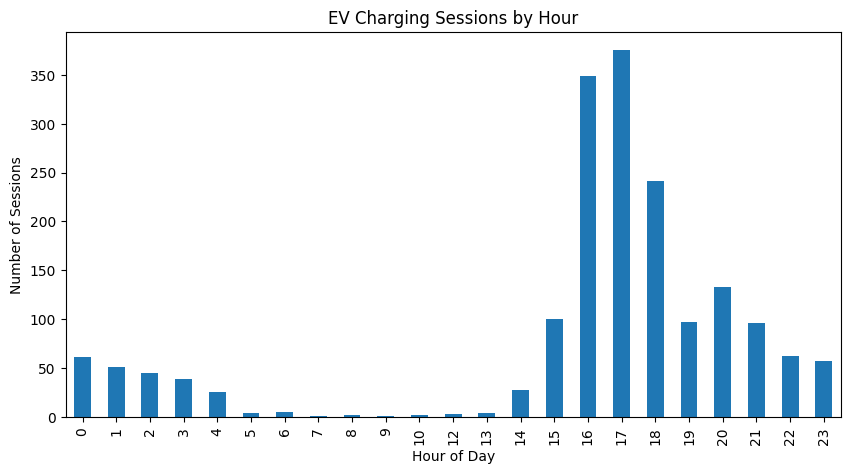

In [5]:
hourly_sessions = df.groupby('hour').size()

plt.figure(figsize=(10,5))
hourly_sessions.plot(kind='bar')

plt.title("EV Charging Sessions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Sessions")

plt.show()

## Revenue Analysis by Hour

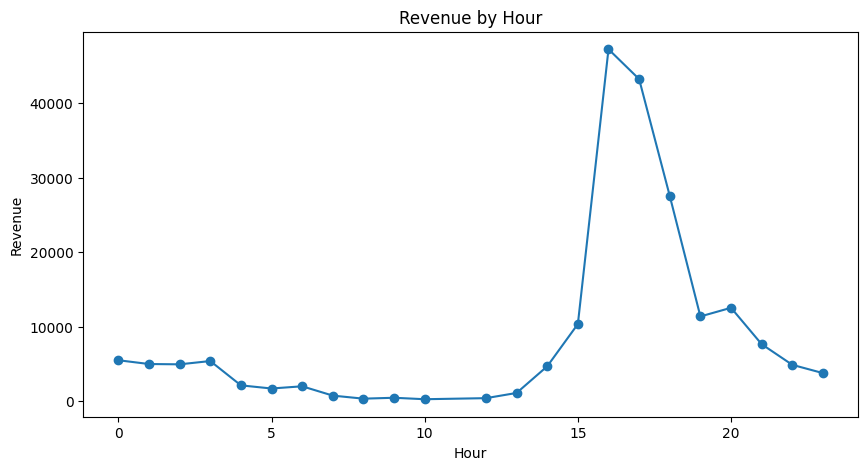

In [6]:
hourly_revenue = df.groupby('hour')['fixed_revenue'].sum()

plt.figure(figsize=(10,5))
hourly_revenue.plot(kind='line', marker='o')

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.show()

## Average Energy Delivered by Day

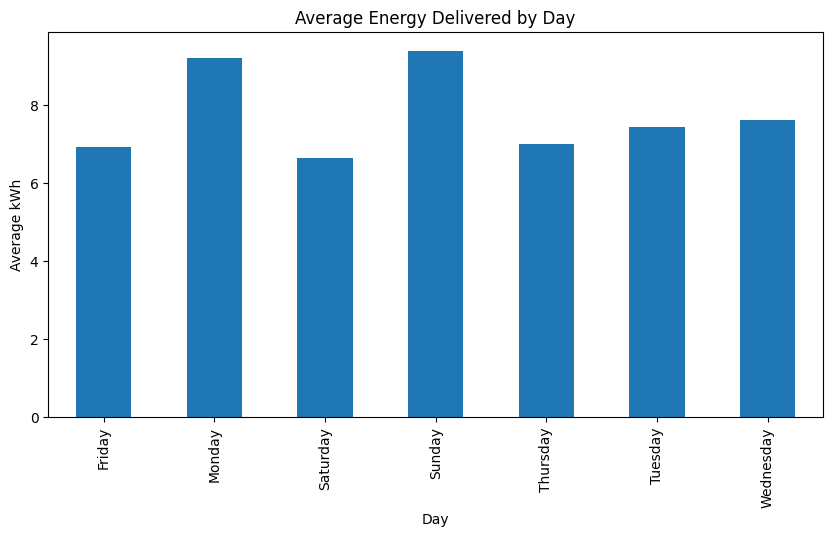

In [7]:
weekday_energy = df.groupby('day_of_week')['kWhDelivered'].mean()

plt.figure(figsize=(10,5))
weekday_energy.plot(kind='bar')

plt.title("Average Energy Delivered by Day")
plt.xlabel("Day")
plt.ylabel("Average kWh")

plt.show()

In [8]:
df['peak_period'] = df['hour'].apply(
    lambda x: 'Peak' if 16 <= x <= 19 else 'Off-Peak'
)

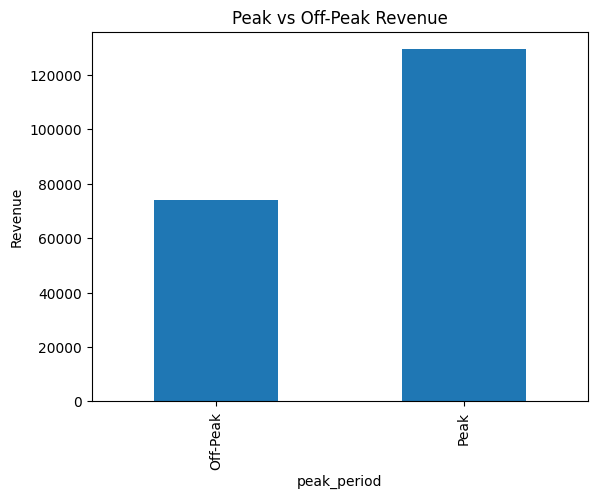

In [9]:
peak_revenue = df.groupby('peak_period')['fixed_revenue'].sum()

peak_revenue.plot(kind='bar')

plt.title("Peak vs Off-Peak Revenue")
plt.ylabel("Revenue")

plt.show()

## Hourly Energy Demand Pattern

In [10]:
hourly_utilization = df.groupby('hour')['kWhDelivered'].sum()

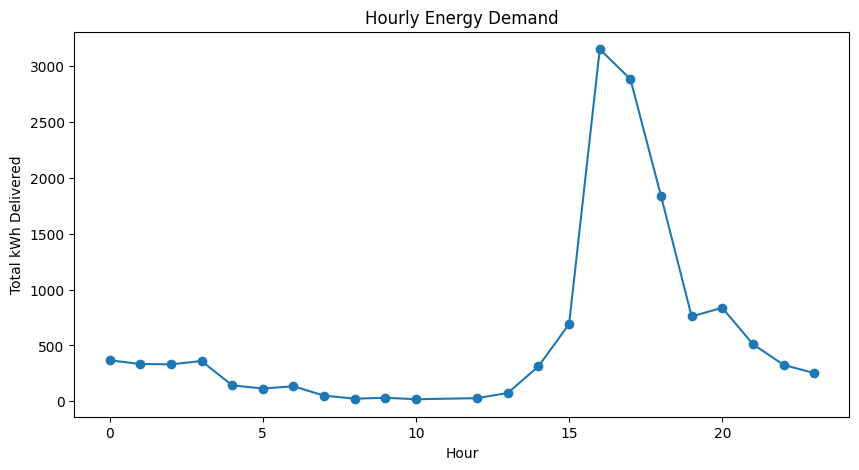

In [11]:
plt.figure(figsize=(10,5))

hourly_utilization.plot(kind='line', marker='o')

plt.title("Hourly Energy Demand")
plt.xlabel("Hour")
plt.ylabel("Total kWh Delivered")

plt.show()

In [12]:
hourly_kwh = df.groupby('hour')['kWhDelivered'].sum()

max_kwh = hourly_kwh.max()

utilization_ratio = hourly_kwh / max_kwh

utilization_ratio

hour
0     0.116714
1     0.105990
2     0.105109
3     0.114456
4     0.045394
5     0.036460
6     0.042745
7     0.016269
8     0.007616
9     0.010167
10    0.006022
12    0.009042
13    0.023851
14    0.099521
15    0.219536
16    1.000000
17    0.915129
18    0.583302
19    0.241122
20    0.265702
21    0.162307
22    0.103685
23    0.080222
Name: kWhDelivered, dtype: float64

## Dynamic Tariff Simulation

In [13]:
dynamic_tariff = {}

for hour, ratio in utilization_ratio.items():

    if ratio > 0.8:
        dynamic_tariff[hour] = 25

    elif ratio < 0.3:
        dynamic_tariff[hour] = 10

    else:
        dynamic_tariff[hour] = 15

dynamic_tariff

{0: 10,
 1: 10,
 2: 10,
 3: 10,
 4: 10,
 5: 10,
 6: 10,
 7: 10,
 8: 10,
 9: 10,
 10: 10,
 12: 10,
 13: 10,
 14: 10,
 15: 10,
 16: 25,
 17: 25,
 18: 15,
 19: 10,
 20: 10,
 21: 10,
 22: 10,
 23: 10}

In [14]:
df['dynamic_tariff'] = df['hour'].map(dynamic_tariff)

In [15]:
df['dynamic_revenue'] = (
    df['kWhDelivered'] * df['dynamic_tariff']
)

## Revenue Gain Analysis

In [16]:
fixed_total = df['fixed_revenue'].sum()

dynamic_total = df['dynamic_revenue'].sum()

revenue_gain = (
    (dynamic_total - fixed_total)
    / fixed_total
) * 100

print("Fixed Revenue:", fixed_total)
print("Dynamic Revenue:", dynamic_total)
print("Revenue Gain %:", revenue_gain)

Fixed Revenue: 203628.4010643816
Dynamic Revenue: 235411.4384514485
Revenue Gain %: 15.60835189047034


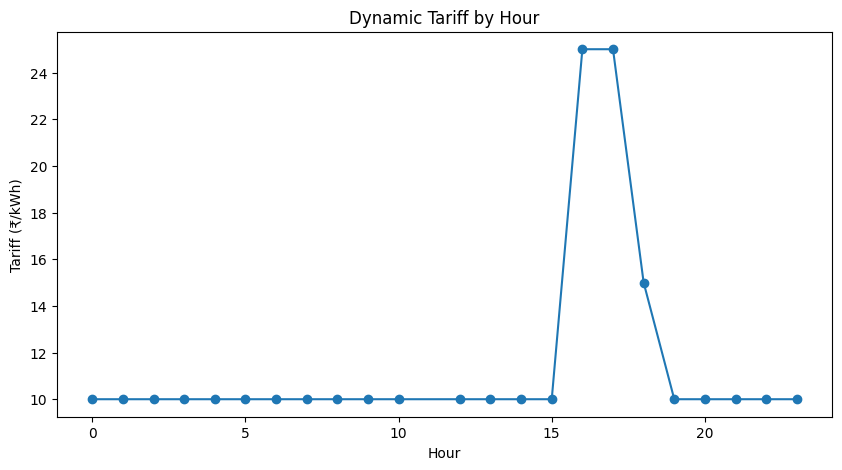

In [17]:
tariff_df = pd.DataFrame({
    'hour': list(dynamic_tariff.keys()),
    'tariff': list(dynamic_tariff.values())
})

plt.figure(figsize=(10,5))

plt.plot(
    tariff_df['hour'],
    tariff_df['tariff'],
    marker='o'
)

plt.title("Dynamic Tariff by Hour")
plt.xlabel("Hour")
plt.ylabel("Tariff (₹/kWh)")

plt.show()